In [1]:
using ManifoldFlows
using OneHotArrays
using CairoMakie
using Optimisers
using MLUtils
using Flux

Shape functions

In [2]:
function circle(n, σ; r = 10)
    T = eltype(σ)
    r = T(r)
    θ = 2 * T(π) .* rand(T, n)
    x = @. cos(θ) * r + σ * $(randn(T, n))
    y = @. sin(θ) * r + σ * $(randn(T, n))
    x, y
end

function spiral(n, σ)
    T = eltype(σ)
    u = 4 * T(π) .* rand(T, n)
    x = @. u * cos(u) + σ * $(randn(T, n))
    y = @. u * sin(u) + σ * $(randn(T, n))
    x, y 
end

function crescent(n, σ; r = 10, t = oftype(σ, π) / 3)
    T = eltype(σ)
    θ = T(π) / 3 .* randn(T, n)
    s = @. (cos(mod2pi(θ)) + 1) / 2
    x = @. cos(θ - t) * r + s * σ * $(randn(T, n))
    y = @. sin(θ - t) * r + s * σ * $(randn(T, n))
    x, y
end

function discretize(x, d, lo, hi)
    for (i, v) in enumerate(range(lo, hi, length = d - 1))
        x < v && return i
    end
    d
end

discretize (generic function with 1 method)

Plot samples of a shape and its discretization.

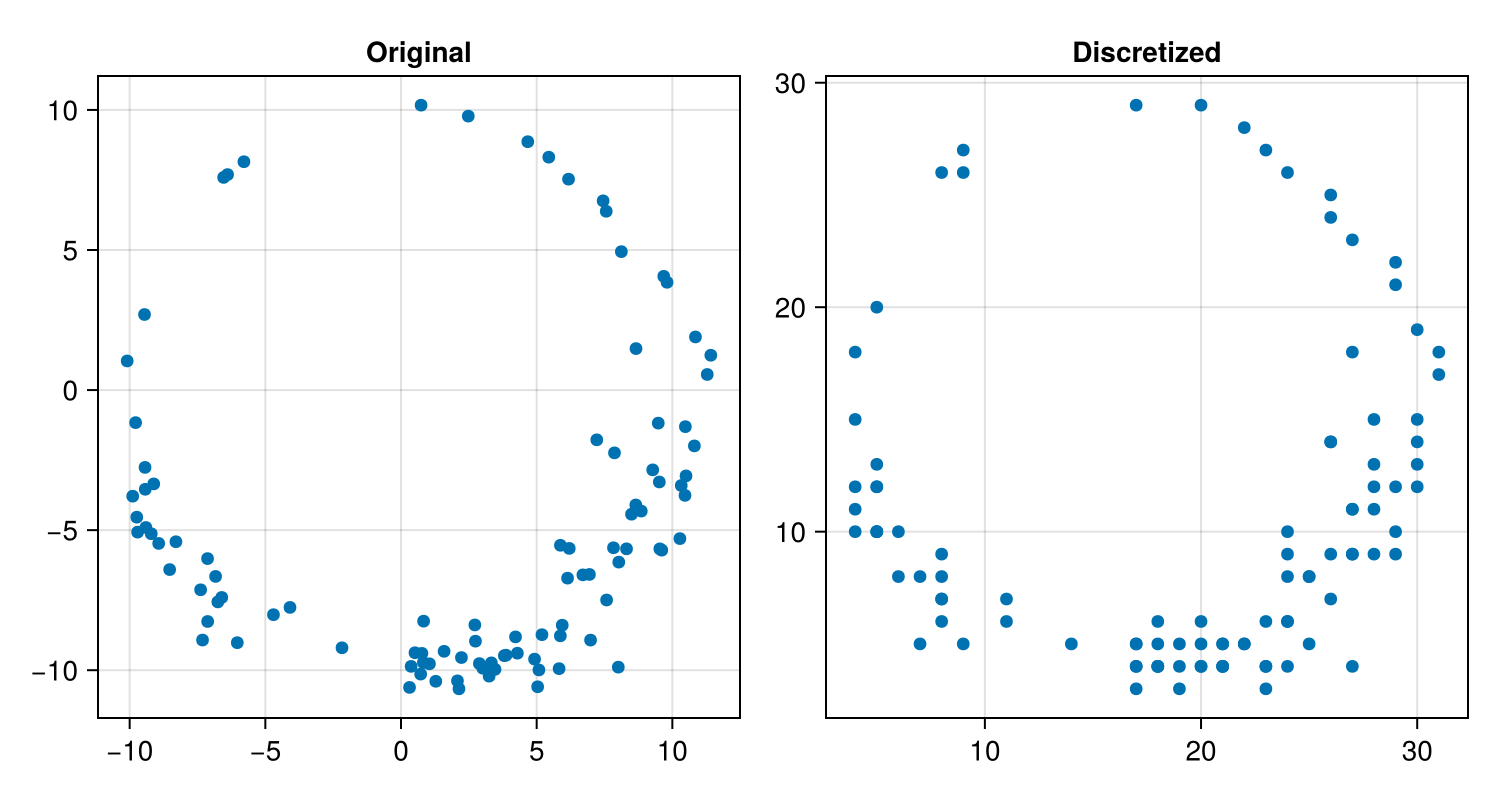

In [3]:
d = 32  # discretization level
σ = 1.0f0  # noise level
n_samples = 100
x, y = crescent(n_samples, σ)
lo, hi = -12, 12
fig = Figure(size = (750, 400))
ax1 = Axis(fig[1,1], aspect = 1, title = "Original")
scatter!(ax1, x, y)
x = discretize.(x, d, lo, hi)
y = discretize.(y, d, lo, hi)
ax2 = Axis(fig[1,2], aspect = 1, title = "Discretized")
scatter!(ax2, x, y)
fig

Define a data sampler.

In [4]:
# define initial distributions
uniform(n_samples, d) = rand(1:d, 2, n_samples)
mask(n_samples, d) = fill(1, 2, n_samples)

# Sample two endpoints X0 and X1.
function sample_data(d, n_samples; σ = σ, lo = -12, hi = 12, init = uniform, shape = crescent)
    x0 = init(n_samples, d)
    x, y = shape(n_samples, σ)
    x = discretize.(x, d, lo, hi)
    y = discretize.(y, d, lo, hi)
    X0 = onehotbatch(x0, 1:d)
    X1 = onehotbatch([x'; y'], 1:d)
    X0, X1
end

sample_data (generic function with 1 method)

Define a model.

In [5]:
# Discrete Flow Model.
struct Model
    d::Int  # the number of states
    N::Int  # the number of dimensions
    layers  # named tuple of layers
end

Flux.@layer Model

function Model(d::Int, N::Int, h::Int)
    embed_time = FourierEmbedding(h)
    embed_state = Embedding(d => h ÷ N)
    transition = Transition(h)
    decode = Dense(h => d * N, bias = false)
    layers = (; embed_time, embed_state, transition, decode)
    Model(d, N, layers)
end

function (f::Model)(t, Xt)
    l = f.layers
    t_embed = l.embed_time(t)
    x = flatten(l.embed_state(Xt))
    x += l.transition(x + l.embed_time(t))
    reshape(l.decode(x), f.d, f.N, :)
end

# Algorithm 22 of AlphaFold3
struct FourierEmbedding{A <: AbstractVector}
    w::A
    b::A
end

# weights are fixed
Flux.@layer FourierEmbedding trainable = ()

function FourierEmbedding(d::Integer)
    w = randn(Float32, d)
    b = randn(Float32, d)
    FourierEmbedding(w, b)
end

(f::FourierEmbedding)(t::AbstractVector) = cos.(2 * Float32(π) .* (f.w .* t' .+ f.b))

# Algorithm 11 of AlphaFold3
struct Transition{N, A, B, C}
    n::N
    a::A
    b::B
    c::C
end

Flux.@layer Transition

function Transition(d::Integer)
    n = LayerNorm(d)
    a = Dense(d => d, swish, bias = false)
    b = Dense(d => d, bias = false)
    c = Dense(d => d, bias = false)
    Transition(n, a, b, c)
end

function (t::Transition)(x)
    x = t.n(x)
    t.c(t.a(x) .* t.b(x))
end

Initialize and train the model.

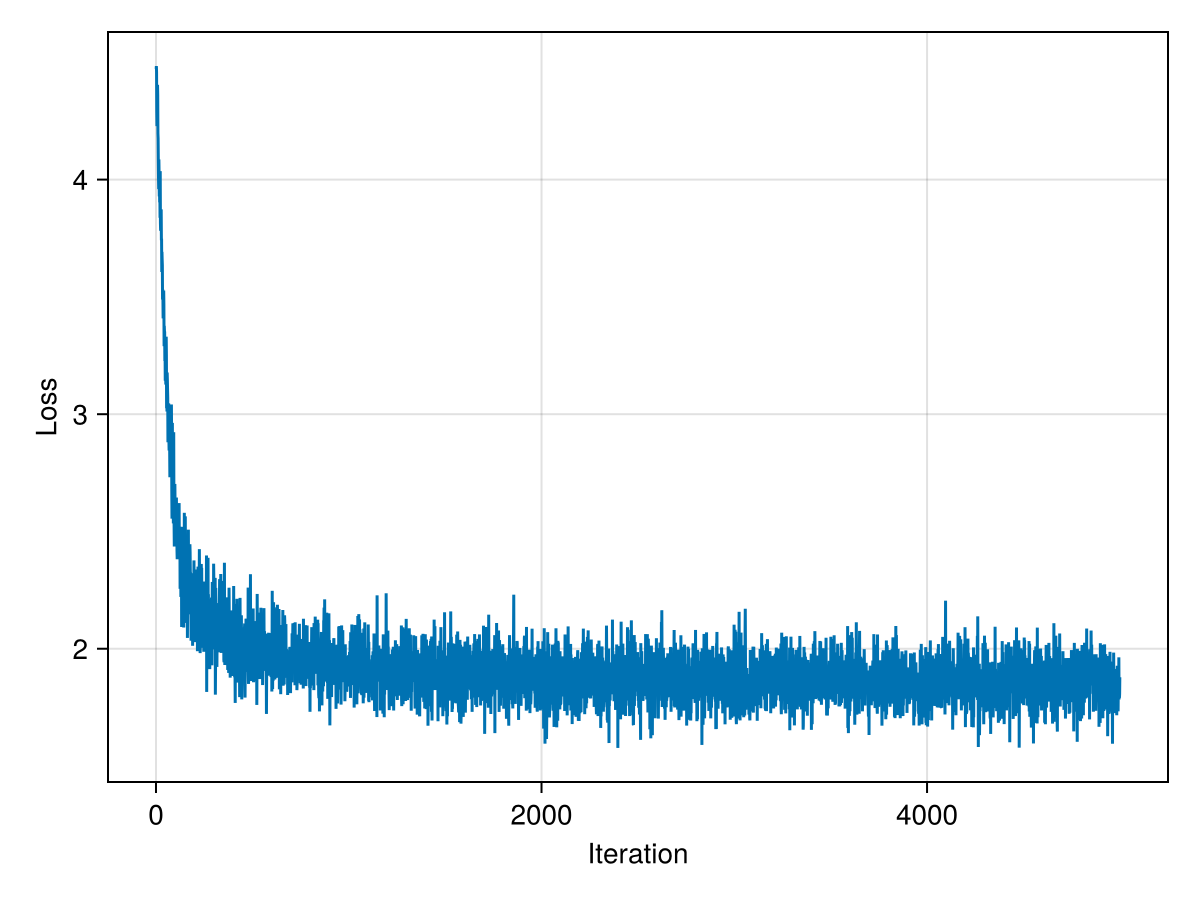

In [6]:
n_iters = 5_000
n_embed_dims = 256
batch_size = 256
flow = DiscreteFlow()
model = Model(d, 2, n_embed_dims)
state = Optimisers.setup(Optimisers.AdamW(eta = 1e-4, lambda = 1e-4), model)
losses = Float32[]
for i in 1:n_iters
    t = rand(Float32, batch_size)
    X0, X1 = sample_data(d, batch_size)
    X0, X1 = MatrixFlowState(X0), MatrixFlowState(X1)
    Xt = interpolate(flow, X0, X1, t')
    x = Xt.x
    loss, grads = Flux.withgradient(model) do f
        ManifoldFlows.loss(flow, f(t, x), X1)
    end
    state, model = Optimisers.update!(state, model, grads[1])
    push!(losses, loss)
end

fig = Figure()
ax = Axis(fig[1,1], xlabel = "Iteration", ylabel = "Loss")
lines!(ax, losses)
fig

Generate samples from the trained model.

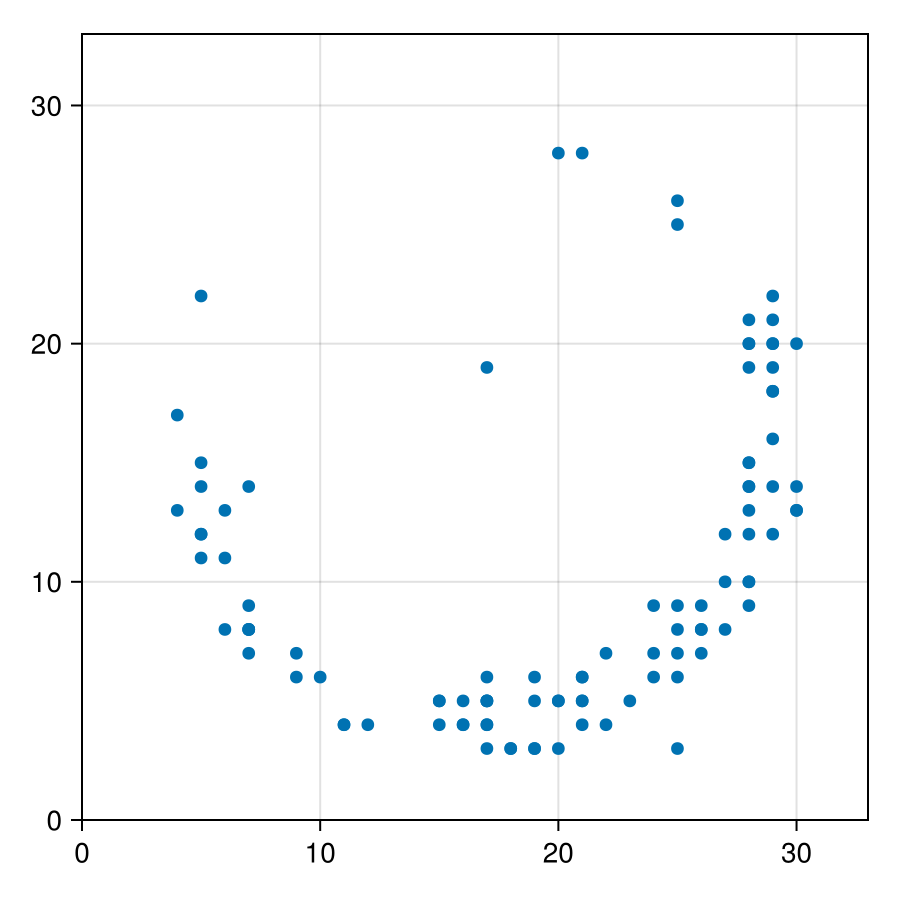

In [7]:
X0, _ = sample_data(d, 100)
X1 = ManifoldFlows.flow(flow, MatrixFlowState(X0), (t, xt) -> model(vec(t), xt.x), steps = 500)
fig = Figure(size = (450, 450))
ax = Axis(fig[1,1], aspect = 1, limits = (0, d + 1, 0, d + 1))
x1 = onecold(X1)
scatter!(ax, x1[1,:], x1[2,:])
fig